In [1]:
import torch

torch.manual_seed(43)


# Lets setup our data first: MNIST

In [2]:
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Dataset, random_split


class MyMNISTDataset(Dataset):
    def __init__(self, root="./data", train=True):
        mnist = MNIST(
            root=root,
            train=train,
            download=True,
        )

        self.images = mnist.data
        self.labels = mnist.targets

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        # Convert uint8 pixels to float32 values in [0, 1]:
        image = image.float() / 255.0

        # Flatten [28, 28] into [784]:
        image = image.flatten()

        return image, label

full_train_dataset = MyMNISTDataset('./data', train=True)
test_dataset = MyMNISTDataset('./data', train=False)

generator = torch.Generator().manual_seed(42)  # Setting the seed ensures that everyone has the same train/validation split.
train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [59000, 1000],
    generator=generator,
)

mini_batch_size = 2

# Define our dataloaders for training, validation, and testing:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=mini_batch_size,
    shuffle=True,
)
validation_dataloader = DataLoader(
    validation_dataset,
    batch_size=mini_batch_size,
    shuffle=False,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=mini_batch_size,
    shuffle=False,
)

# And then create a dataset with only 2 examples

In [3]:
from torch.utils.data import Subset

dummy_train_dataset = Subset(dataset=full_train_dataset, indices=[0, 1])

batch_size = 2

dummy_train_dataloader = DataLoader(
    dummy_train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

In [4]:
training_example_1 = dummy_train_dataset[0]
training_example_2 = dummy_train_dataset[1]


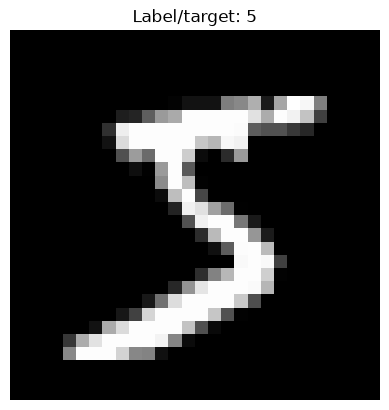

In [5]:

import matplotlib.pyplot as plt

image, label = training_example_1

plt.imshow(image.reshape(28, 28), cmap="gray")
plt.title(f"Label/target: {label}")
plt.axis("off")
plt.show()

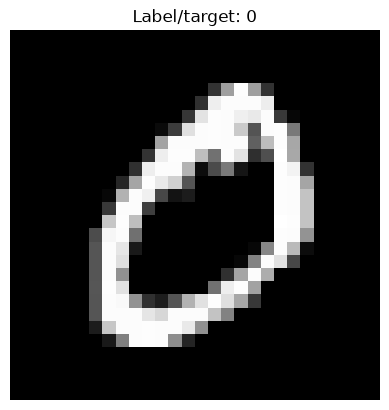

In [6]:
image, label = training_example_2

plt.imshow(image.reshape(28, 28), cmap="gray")
plt.title(f"Label/target: {label}")
plt.axis("off")
plt.show()

# What do we want to estimate/predict?

$y$ is our target. We want our model to estimate $y$ given $x$.

For each example in our dataset, we have an input and a training target. 

E.g., our dataset of size 2, has two pairs of inputs and targets.

In [7]:
dummy_train_dataloader_iter = iter(dummy_train_dataloader)
batch = next(dummy_train_dataloader_iter)
input, target = batch

In [8]:
input.shape

torch.Size([2, 784])

In [9]:
target

tensor([0, 5])

In [10]:
target.shape

torch.Size([2])

In [11]:
# Lets convert these to one-hot encoded vectors to match up to our number of outputs:

import torch.nn.functional as F

number_of_classes = 10  # Number of classes in the dataset.

target = F.one_hot(target, num_classes=number_of_classes).float()

target

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

# Our model

$$
\hat{y} = xW + b
$$

A multivariate, multi-output linear regression model.

W and b will be our learnable parameters, which we can represent as:

$$
\theta = \{W, b\}
$$

# Using nn.Parameter

This records the mathematical operations during forward so that gradients can be computed during backward propagation.

In [12]:
from torch import nn

input_size = input.shape[1]  # This is 784, since each image is flattened into a vector of length 28*28=784.
output_size = 10  # We have 10 classes, one for each digit (0-9).

w = nn.Parameter(torch.randn(input_size, output_size))
b = nn.Parameter(torch.randn(output_size))
z = torch.matmul(input, w) + b


In [13]:
w

Parameter containing:
tensor([[-0.5621, -0.4143, -1.3001,  ...,  0.2977, -0.0678, -0.0886],
        [-0.3124, -0.3552,  0.7297,  ..., -0.2947, -0.7662, -0.9962],
        [-0.2345, -0.5367,  1.1296,  ...,  1.8462, -0.4772, -1.8291],
        ...,
        [ 0.2615, -0.4046,  1.1370,  ...,  1.1727,  0.0432,  1.0619],
        [ 1.0040,  2.5915, -0.2665,  ...,  0.7251,  1.2004, -0.8897],
        [ 0.8916, -0.4266,  0.5990,  ...,  0.0214, -0.2781, -0.0394]],
       requires_grad=True)

In [14]:
w.shape

torch.Size([784, 10])

In [15]:
w.grad

In [16]:
w.grad == None

True

In [17]:
b

Parameter containing:
tensor([ 0.1402, -0.5657,  0.8781, -1.4337,  0.8442, -0.1159,  0.5891,  0.2567,
         0.4219, -0.1380], requires_grad=True)

In [18]:
b.shape

torch.Size([10])

In [19]:
b.grad

In [20]:
z

tensor([[ -1.3961,  -3.2932, -11.4373,  -6.5574,   7.5730, -16.9522,  -8.0102,
           3.0316,   3.7876,  -3.7760],
        [  0.1800,   3.7741,  -0.9267,  -7.7642,   3.2120, -23.4286,   2.2727,
           0.6650,   1.3601,  -4.3192]], grad_fn=<AddBackward0>)

In [21]:
z.grad

/tmp/ipykernel_27574/4110045842.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /__w/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:493.)
  z.grad


In [22]:
z.shape

torch.Size([2, 10])

# What is the error/difference/loss/cost between our output and target?

This tells us how "far away" our model is from correctly estimating the target for the given input.

E.g., we could use "mean squared error" between the output and the target as the loss.

$$
  \mathcal{L}
  = \frac{1}{N}\sum_{i=1}^{N}
  \left(
  \frac{1}{D}\sum_{j=1}^{D}(z_{ij}-y_{ij})^2
  \right)
  $$



In [23]:
target

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

In [24]:
loss = ((z - target) ** 2).mean(dim=1).mean(dim=0)
loss

tensor(67.2843, grad_fn=<MeanBackward1>)

# Time to learn: Lets update our parameters to minimise the loss


The goal is to find parameters $\theta$ that minimize a loss function:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$

  First, calculate the gradient of the loss with respect to the parameters:

  $$
  \nabla_{\theta}\mathcal{L}(\theta)
  $$

  
Later, we will use this to update our parameters.

In [25]:
w.grad

In [26]:
loss.backward()

In [27]:
w.grad

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [28]:
w.grad.shape

torch.Size([784, 10])

In [29]:
w.grad.min(), w.grad.max()

(tensor(-4.1056), tensor(1.0700))

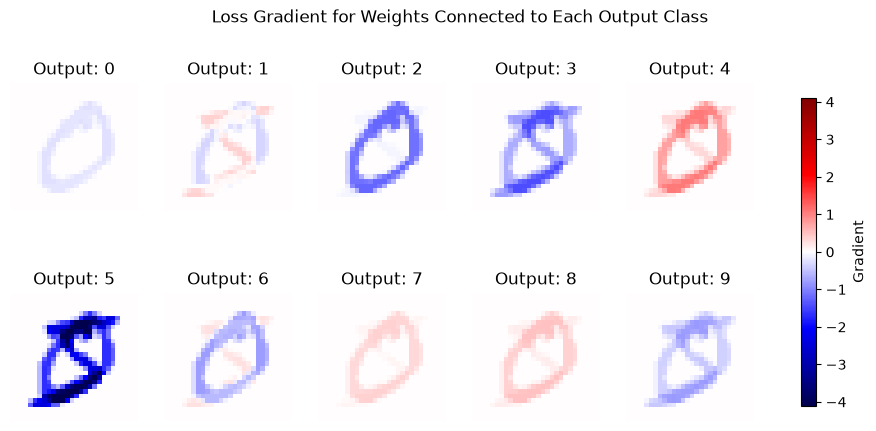

In [30]:
grads = w.grad.detach().cpu()
limit = grads.abs().max().item()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit, ax in enumerate(axes.flat):
    im = ax.imshow(
        grads[:, digit].reshape(28, 28),
        cmap="seismic",
        vmin=-limit,
        vmax=limit,
    )
    ax.set_title(f"Output: {digit}")
    ax.axis("off")

fig.suptitle("Loss Gradient for Weights Connected to Each Output Class")
fig.colorbar(im, ax=axes, shrink=0.8, label="Gradient")
plt.show()

# Optimizer

Then update the parameters in the direction opposite to the gradient:

  $$
  \theta_{t+1}
  =
  \theta_t
  -
  \eta \nabla_{\theta}\mathcal{L}(\theta_t)
  $$

  where:

  - $\theta_t$ represents the current model parameters, such as weights and
  biases
  - $\eta$ is the learning rate
  - $\nabla_{\theta}\mathcal{L}(\theta_t)$ is the gradient of the loss

  For a weight $w$ and bias $b$, the updates are:

  $$
  w_{t+1}
  =
  w_t
  -
  \eta \frac{\partial \mathcal{L}}{\partial w}
  $$

  $$
  b_{t+1}
  =
  b_t
  -
  \eta \frac{\partial \mathcal{L}}{\partial b}
  $$


![](./images/gradient_descent-2.png)

In [31]:
w

Parameter containing:
tensor([[-0.5621, -0.4143, -1.3001,  ...,  0.2977, -0.0678, -0.0886],
        [-0.3124, -0.3552,  0.7297,  ..., -0.2947, -0.7662, -0.9962],
        [-0.2345, -0.5367,  1.1296,  ...,  1.8462, -0.4772, -1.8291],
        ...,
        [ 0.2615, -0.4046,  1.1370,  ...,  1.1727,  0.0432,  1.0619],
        [ 1.0040,  2.5915, -0.2665,  ...,  0.7251,  1.2004, -0.8897],
        [ 0.8916, -0.4266,  0.5990,  ...,  0.0214, -0.2781, -0.0394]],
       requires_grad=True)

In [32]:
learning_rate = 1e-2

with torch.no_grad():
    w -= learning_rate * w.grad  # w_t+1 = w_t - learning_rate * gradient
    b -= learning_rate * b.grad  # b_t+1 = b_t - learning_rate * gradient

In [33]:
w

Parameter containing:
tensor([[-0.5621, -0.4143, -1.3001,  ...,  0.2977, -0.0678, -0.0886],
        [-0.3124, -0.3552,  0.7297,  ..., -0.2947, -0.7662, -0.9962],
        [-0.2345, -0.5367,  1.1296,  ...,  1.8462, -0.4772, -1.8291],
        ...,
        [ 0.2615, -0.4046,  1.1370,  ...,  1.1727,  0.0432,  1.0619],
        [ 1.0040,  2.5915, -0.2665,  ...,  0.7251,  1.2004, -0.8897],
        [ 0.8916, -0.4266,  0.5990,  ...,  0.0214, -0.2781, -0.0394]],
       requires_grad=True)

# Zero your gradients!

Now, we just updated our parameters based on the gradients. 

We have to reset our gradients for the next update.

In [34]:
w.grad

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [35]:
w.grad.min(), w.grad.max()

(tensor(-4.1056), tensor(1.0700))

In [36]:
w.grad.zero_()

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [37]:
w.grad.min(), w.grad.max()

(tensor(0.), tensor(0.))

# Training over a large dataset

Before our training data had two examples. 

Instead, lets use a large dataset, and iterate over it in mini-batches.

We need the mini-batches as the dataset is too large to train the model all in one go.

So, as opposed to gradient descent, where every epoch (which means training over your entire dataset) in one go, we will do stochastic gradient descent.

#### Stochastic gradient descent: performing gradient descent on mini-batches of your dataset, rather than your whole dataset.

Therefore, one epoch will consist of multiple mini-batches; your model will be updated mulitple times per epoch.

In [38]:
len(train_dataset)

59000

In [39]:
train_dataloader.batch_size

2

In [40]:
from tqdm.auto import tqdm

# Define our hyperparameters:
number_of_epochs = 3
learning_rate = 0.001

for epoch in range(number_of_epochs):

    for mini_batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{number_of_epochs}"):
        x = mini_batch[0]
        y = mini_batch[1]

        # Convert the labels to one-hot encoded vectors:
        y_one_hot = F.one_hot(y, num_classes=number_of_classes).float()

        z = torch.matmul(x, w) + b
        loss = ((z - y_one_hot)**2).mean(dim=1).mean(dim=0)

        loss.backward()
        
        with torch.no_grad():
            w -= learning_rate * w.grad
            b -= learning_rate * b.grad
        
        w.grad.zero_()
        b.grad.zero_()

    print(f"Loss: {loss.item():.4f}")

Epoch 1/3:   0%|          | 0/29500 [00:00<?, ?it/s]

Loss: 7.3594


Epoch 2/3:   0%|          | 0/29500 [00:00<?, ?it/s]

Loss: 1.5299


Epoch 3/3:   0%|          | 0/29500 [00:00<?, ?it/s]

Loss: 2.1540


In [41]:
output = torch.matmul(x, w) + b
output

tensor([[-1.0284,  0.6934, -1.5652,  0.5920,  1.2164, -0.2301,  1.1940, -0.3935,
         -1.2380,  3.0766],
        [-0.8853, -0.9114, -0.3361,  0.2262, -0.4046, -1.7858,  1.2112, -0.3197,
          0.3937,  4.5631]], grad_fn=<AddBackward0>)

In [42]:
output.argmax(dim=1)

tensor([9, 9])

In [43]:
y

tensor([2, 9])

# A feedforward neural network layer

$\hat{y} = xW + b$

In [44]:
# Before
w = torch.randn(784, 10, requires_grad=True)
b = torch.randn(10, requires_grad=True)
z = torch.matmul(input, w) + b

# After
layer = torch.nn.Linear(in_features=784, out_features=10)

In [45]:
layer

Linear(in_features=784, out_features=10, bias=True)

In [46]:
layer(x)  # Equivalent to z = torch.matmul(x, w) + b

tensor([[ 0.2974, -0.1320, -0.3747,  0.2091, -0.1156, -0.1655, -0.2396,  0.2610,
          0.3023, -0.2833],
        [-0.3580,  0.1325, -0.0136, -0.1277,  0.1569,  0.0693, -0.2522, -0.2064,
          0.3193, -0.1103]], grad_fn=<AddmmBackward0>)

# torch.nn.Module: How we actually construct models

This allows us to:
- Define the learnable parameters in __init__
- Have a callable forward propagation function/definition.

In [47]:
class AffineTransform(nn.Module):
    def __init__(self, in_features, out_features, bias=True):

        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias

        self.w = nn.Parameter(torch.randn(self.in_features, self.out_features, requires_grad=True))
        if bias:
            self.b = nn.Parameter(torch.randn(self.out_features, requires_grad=True))

    def forward(self, x):
        if self.bias:
            return torch.matmul(x, self.w) + self.b
        else:
            return torch.matmul(x, self.w)

    # def extra_repr(self):
    #     return (
    #         f"in_features={self.in_features}, "
    #         f"out_features={self.out_features}, "
    #         f"bias={self.bias}"
    #     )

In [48]:
same_layer = AffineTransform(784, 10)


In [49]:
layer

Linear(in_features=784, out_features=10, bias=True)

In [50]:
same_layer

AffineTransform()

# A deep neural network: Feedforward neural network

This goes by many names:
- Multi-layer perceptron
- Deep neural network
- Fully-connected neural network
- Feedforward neural network

In [51]:
class FeedforwardNeuralNetwork(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, num_hidden_layers):
        super().__init__()

        layers = []

        for layer_index in range(num_hidden_layers):
            
            input_size = in_features if layer_index == 0 else hidden_features

            layers.append(nn.Linear(input_size, hidden_features))  # Wx + b.
            layers.append(nn.ReLU())  # This is the activation function applied after each hidden layer.

        layers.append(nn.Linear(hidden_features, out_features))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [52]:
model = FeedforwardNeuralNetwork(784, 16, 10, 2)
model

FeedforwardNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

![](./images/featured.jpg)

# What is an activation function? 

We add an activation function to our layers to make them non-linear; this allows us to learn more complex functions.

$\hat{y} = \sigma(xW + b)$

![](./images/activations.png)

# Torch has classes for the loss and the optimiser as well

In [53]:
loss = torch.nn.functional.mse_loss(z, target)  # Mean Squared Error
loss

tensor(71.7475, grad_fn=<MseLossBackward0>)

In [54]:
optimiser = torch.optim.SGD(model.parameters(), lr=0.001)  # This does w = w - learning_rate * w.grad for us.


In [55]:
params = list(model.parameters())  # This prints out the learnable parameters of our model.
print(params)

[Parameter containing:
tensor([[-0.0016, -0.0232,  0.0184,  ...,  0.0216,  0.0231,  0.0028],
        [ 0.0194, -0.0199,  0.0114,  ..., -0.0225, -0.0266, -0.0124],
        [ 0.0237, -0.0047, -0.0106,  ...,  0.0252, -0.0030, -0.0039],
        ...,
        [-0.0203,  0.0216,  0.0003,  ..., -0.0042,  0.0231, -0.0304],
        [-0.0201, -0.0011, -0.0134,  ..., -0.0118,  0.0280, -0.0095],
        [ 0.0184,  0.0068,  0.0093,  ...,  0.0330, -0.0104, -0.0138]],
       requires_grad=True), Parameter containing:
tensor([ 0.0207,  0.0102,  0.0279,  0.0011, -0.0284,  0.0176, -0.0042, -0.0240,
        -0.0110, -0.0136,  0.0121,  0.0185, -0.0161, -0.0204,  0.0300, -0.0323],
       requires_grad=True), Parameter containing:
tensor([[-0.1829,  0.1565, -0.0507, -0.1350, -0.0020,  0.0513, -0.0281,  0.1021,
         -0.1855, -0.0838, -0.2250, -0.0502,  0.1628,  0.1865, -0.0454, -0.0504],
        [-0.1023, -0.1235,  0.2323, -0.0765, -0.1757,  0.1465, -0.1064, -0.2073,
          0.0697, -0.1634,  0.1340,  0

In [56]:
for name, param in model.named_parameters():
    print(name, param.shape)

network.0.weight torch.Size([16, 784])
network.0.bias torch.Size([16])
network.2.weight torch.Size([16, 16])
network.2.bias torch.Size([16])
network.4.weight torch.Size([10, 16])
network.4.bias torch.Size([10])


In [57]:
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total)

13002


In [58]:
model(x)

tensor([[ 0.0962,  0.0209,  0.0813, -0.1066,  0.0600,  0.1904,  0.0094, -0.1156,
          0.1830,  0.1298],
        [ 0.0912,  0.0450,  0.0400, -0.1306, -0.0284,  0.2432,  0.0261, -0.0853,
          0.1325,  0.1131]], grad_fn=<AddmmBackward0>)

In [59]:
# Define our hyperparameters:
number_of_epochs = 5
learning_rate = 0.001

# Lets increase our mini-batch size to 32 for the training set:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

# Define our model:
model = FeedforwardNeuralNetwork(784, 16, 10, 2)

# Define our optimiser:
optimiser = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Train the model:
for epoch in range(number_of_epochs):

    model.train()  # Set the model to training mode (enables training features)
    for mini_batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{number_of_epochs}"):

        input, target = mini_batch

        # Convert the labels to one-hot encoded vectors:
        target_one_hot = F.one_hot(target, num_classes=number_of_classes).float()
        
        output = model(input)
        loss = torch.nn.functional.mse_loss(output, target_one_hot)
        
        loss.backward()
        optimiser.step()
        optimiser.zero_grad()

    # Evaluate the model on the validation dataset:
    model.eval()  # Set the model to evaluation mode (disables training features)

    val_accuracy = 0
    val_loss = 0
    for mini_batch in validation_dataloader:
        input, target = mini_batch

        # Convert the labels to one-hot encoded vectors:
        target_one_hot = F.one_hot(target, num_classes=number_of_classes).float()

        with torch.no_grad():  # Disable gradient computation for evaluation
            output = model(input)

            predictions = torch.argmax(output, dim=1)  # Which class had the highest score?

            val_accuracy += (predictions == target).sum().item()  # How accurate was it?
            val_loss += torch.nn.functional.mse_loss(output, target_one_hot).item()

    val_accuracy /= len(validation_dataset)
    val_loss /= len(validation_dataloader)
    print(f"Validation accuracy for epoch {epoch + 1}: {val_accuracy:.4f}")
    print(f"Validation loss for epoch {epoch + 1}: {val_loss:.4f}")    

Epoch 1/5:   0%|          | 0/1844 [00:00<?, ?it/s]

Validation accuracy for epoch 1: 0.1160
Validation loss for epoch 1: 0.0942


Epoch 2/5:   0%|          | 0/1844 [00:00<?, ?it/s]

Validation accuracy for epoch 2: 0.1290
Validation loss for epoch 2: 0.0906


Epoch 3/5:   0%|          | 0/1844 [00:00<?, ?it/s]

Validation accuracy for epoch 3: 0.2000
Validation loss for epoch 3: 0.0888


Epoch 4/5:   0%|          | 0/1844 [00:00<?, ?it/s]

Validation accuracy for epoch 4: 0.2290
Validation loss for epoch 4: 0.0878


Epoch 5/5:   0%|          | 0/1844 [00:00<?, ?it/s]

Validation accuracy for epoch 5: 0.2590
Validation loss for epoch 5: 0.0869


In [60]:
# Testing:
model.eval()  # Set the model to evaluation mode (disables training features)

test_accuracy = 0
test_loss = 0
for batch in test_dataloader:
    input, target = batch
    
    with torch.no_grad():  # Disable gradient computation for evaluation

        output = model(input)

        predictions = torch.argmax(output, dim=1)  # Which class had the highest score?

        test_accuracy += (predictions == target).sum().item()  # How accurate was it?

        test_loss += torch.nn.functional.cross_entropy(output, target).item()

test_accuracy /= len(test_dataset)
test_loss /= len(test_dataloader)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.2615
Test loss: 2.2809


# Lets see it in action



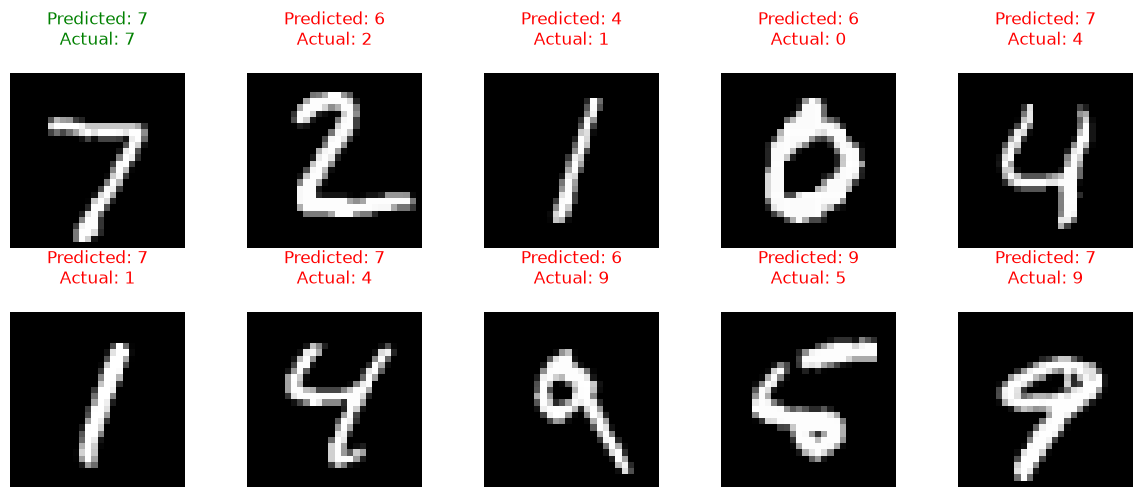

In [61]:
model.eval()

test_dataloader = DataLoader(
    test_dataset,
    batch_size=10,
    shuffle=False,
)

x, y = next(iter(test_dataloader))

with torch.no_grad():
    logits = model(x)
    predictions = logits.argmax(dim=1)

number_to_show = 10

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for index, axis in enumerate(axes.flat):
    image = x[index].reshape(28, 28)  # Images were flattened from [28, 28] to [784].


    axis.imshow(image, cmap="gray")
    axis.set_title(
        f"Predicted: {predictions[index].item()}\n"
        f"Actual: {y[index].item()}\n",
        color="green" if predictions[index] == y[index] else "red",
    )
    axis.axis("off")

plt.tight_layout()
plt.show()